# Assignment

## Data Preparation

### **Fixed Sequence Length (C = 30)**

After trimming, all sequences still had different lengths depending on the leght of the squat. Instead of using zero padding, every sequence was converted into a fixed sequence length of C = 30 frames by selecting equally spaced frames across the entire movement. This ensured that all videos had the same dimension while still preserving information from the full squat motion. Sequences shorter than 30 frames were excluded from the dataset.


### **Features**

For every selected frame, MediaPipe pose landmarks were used to extract:

* Head
* Left/right shoulder
* Left/right elbow
* Left/right hand
* Left/right hip
* Left/right knee
* Left/right foot

For each joint, the following features were stored:

* x-coordinate
* y-coordinate
* z-coordinate

This resulted in: $\quad 13 \text{ joints} \times 3 \text{ features} = 39 \text{ features per frame}$

After converting each sequence to $30$ frames: $\quad 30 \text{ frames} \times 39 \text{ features}$

Each video sequence was finally flattened into one row in a CSV file.


### **Target**

The target values were loaded from a separate CSV file containing:

* video filename
* exercise score

The original scores were scaled into the interval $0-4$ using MinMax scaling. Videos marked as not squat were manually removed before scaling to avoid affecting the score distribution.

## RNN models

We test the performance of different RNN models, one simple, one LSTM and one GRU.

### Data Prep

In [52]:
import numpy as np
import os
import json
import torch
from torchinfo import summary
import data_functions as dfunc

folder_path = "../../MainProject/data/mediapipe_trimmed_world"
score_path = "../../MainProject/data/video_scores.csv"

device = torch.device("cpu")

random_state = 42

train_data, test_data, train_y, test_y = dfunc.load_folder_with_split(
    folder_path=folder_path,
    target_path=score_path,
    test_size=0.2,
    random_state=random_state,
    select_rows=True,
    num_rows=30)

X_test = dfunc.augument_data(test_data, mirror_axis=[[False, False, False]], rotations=[0])
Y_test = torch.tensor(test_y, dtype=torch.float32).reshape(-1, 1)

In [53]:
RNN_folder_path = "scoring_models/RNN_models"

RNNcheckpoint = torch.load(os.path.join(RNN_folder_path, "SimpleRNNModel_scoring_checkpoint.pth"), weights_only=False)
LSTMcheckpoint = torch.load(os.path.join(RNN_folder_path, "LSTMModel_scoring_checkpoint.pth"), weights_only=False)
GRUcheckpoint = torch.load(os.path.join(RNN_folder_path, "GRUModel_scoring_checkpoint.pth"), weights_only=False)

RNN_checkpoints = [RNNcheckpoint, LSTMcheckpoint, GRUcheckpoint]

RNN_models = []
for checkpoint in RNN_checkpoints:
    model = checkpoint["model_config"]["model_type"](
        checkpoint["model_config"]["input_size"],
        checkpoint["model_config"]["hidden_size"],
        checkpoint["model_config"]["depth"],
        checkpoint["model_config"]["num_of_classification_labels"],
    ).to(device)
    model.load_state_dict(checkpoint["model_state_dict"])
    RNN_models.append(model)

for i, model in enumerate(RNN_models):
    if model is not None:
        print(f"{model.to_string()} successfully loaded!")
        print(f"Parameters:")
        for parameter, value in RNN_checkpoints[i]["model_config"].items():
            print(f"\t{parameter}: {value}")
        print()

SimpleRNNModel successfully loaded!
Parameters:
	model_type: <class 'RNN_models.SimpleRNNModel'>
	classifier: False
	input_size: 39
	hidden_size: 32
	depth: 5
	num_of_classification_labels: 1
	lr: 0.0001
	loss_func: <class 'torch.nn.modules.loss.MSELoss'>
	optimizer: <class 'torch.optim.adam.Adam'>
	batch_size: 256
	patience: 3
	epochs: 100

LSTMModel successfully loaded!
Parameters:
	model_type: <class 'RNN_models.LSTMModel'>
	classifier: False
	input_size: 39
	hidden_size: 32
	depth: 5
	num_of_classification_labels: 1
	lr: 0.0001
	loss_func: <class 'torch.nn.modules.loss.MSELoss'>
	optimizer: <class 'torch.optim.adam.Adam'>
	batch_size: 256
	patience: 3
	epochs: 100

GRUModel successfully loaded!
Parameters:
	model_type: <class 'RNN_models.GRUModel'>
	classifier: False
	input_size: 39
	hidden_size: 32
	depth: 5
	num_of_classification_labels: 1
	lr: 0.0001
	loss_func: <class 'torch.nn.modules.loss.MSELoss'>
	optimizer: <class 'torch.optim.adam.Adam'>
	batch_size: 256
	patience: 3
	epo


Model: SimpleRNNModel
MSE:  0.0596
RMSE: 0.2442
MAE:  0.1552
R²:   0.9225


/var/folders/h2/wsl1mbxn7q7_v_9543b88fx00000gn/T/ipykernel_8368/2824946392.py:40: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  residuals = Y_test - predictions


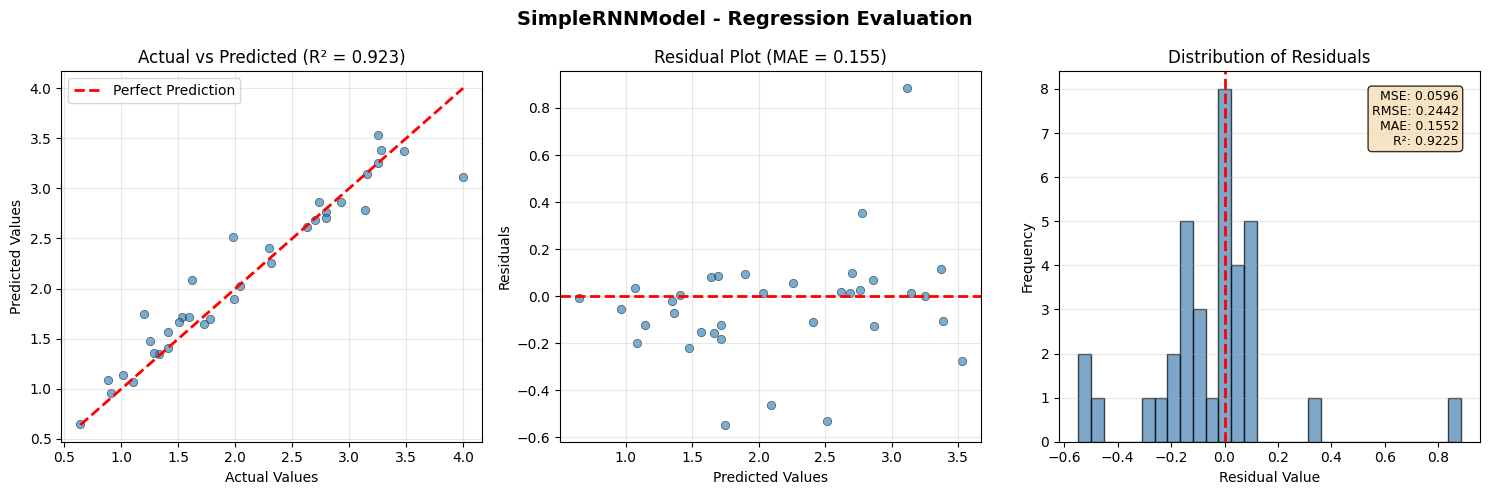


Model: LSTMModel
MSE:  0.0586
RMSE: 0.2421
MAE:  0.1345
R²:   0.9238


/var/folders/h2/wsl1mbxn7q7_v_9543b88fx00000gn/T/ipykernel_8368/2824946392.py:40: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  residuals = Y_test - predictions


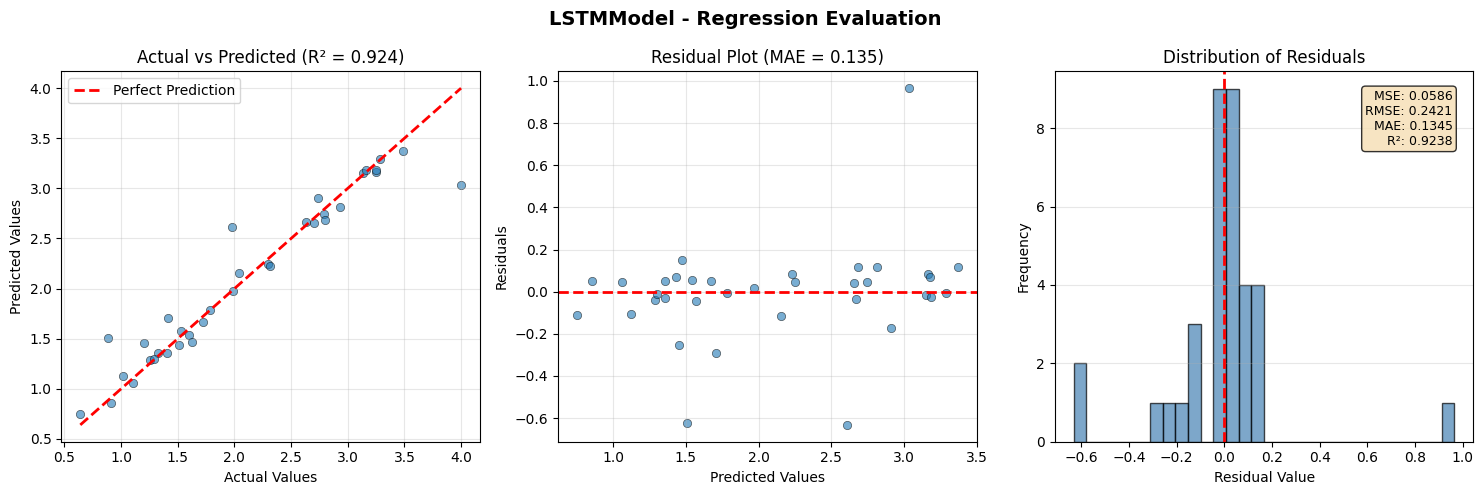


Model: GRUModel
MSE:  0.1002
RMSE: 0.3166
MAE:  0.1770
R²:   0.8697


/var/folders/h2/wsl1mbxn7q7_v_9543b88fx00000gn/T/ipykernel_8368/2824946392.py:40: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  residuals = Y_test - predictions


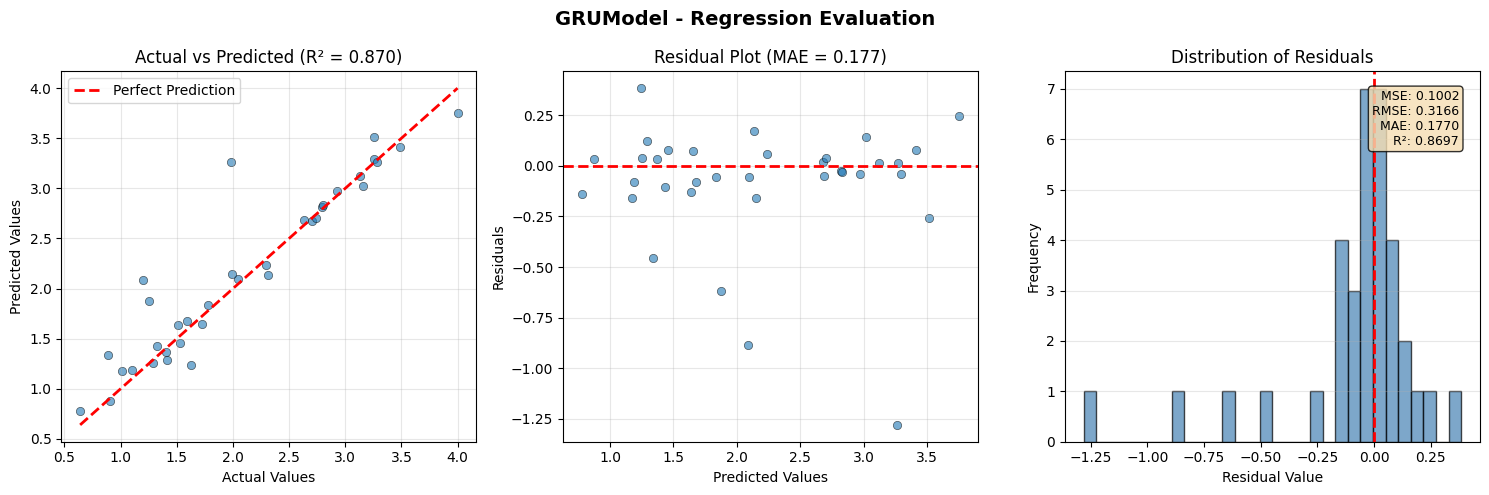

In [54]:
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

for i, model in enumerate(RNN_models):
    model.eval()
    with torch.no_grad():
        X_test_tensor = torch.as_tensor(X_test, dtype=torch.float32, device=device)
        predictions = model(X_test_tensor).cpu().numpy()
        
        # Calculate metrics
        mse = mean_squared_error(Y_test, predictions)
        rmse = np.sqrt(mse)
        mae = mean_absolute_error(Y_test, predictions)
        r2 = r2_score(Y_test, predictions)
        
        # Print metrics
        print(f"\n{'='*50}")
        print(f"Model: {RNN_models[i].to_string()}")
        print(f"{'='*50}")
        print(f"MSE:  {mse:.4f}")
        print(f"RMSE: {rmse:.4f}")
        print(f"MAE:  {mae:.4f}")
        print(f"R²:   {r2:.4f}")
        
        # Create visualization
        fig, axes = plt.subplots(1, 3, figsize=(15, 5))
        fig.suptitle(f"{RNN_models[i].to_string() if hasattr(RNN_models[i], 'to_string') else type(model).__name__} - Regression Evaluation", 
                     fontsize=14, fontweight='bold')
        
        # Plot 1: Actual vs Predicted
        axes[0].scatter(Y_test, predictions, alpha=0.6, edgecolors='k', linewidth=0.5)
        axes[0].plot([Y_test.min(), Y_test.max()], [Y_test.min(), Y_test.max()], 'r--', lw=2, label='Perfect Prediction')
        axes[0].set_xlabel('Actual Values')
        axes[0].set_ylabel('Predicted Values')
        axes[0].set_title(f'Actual vs Predicted (R² = {r2:.3f})')
        axes[0].legend()
        axes[0].grid(True, alpha=0.3)
        
        # Plot 2: Residuals
        residuals = Y_test - predictions
        axes[1].scatter(predictions, residuals, alpha=0.6, edgecolors='k', linewidth=0.5)
        axes[1].axhline(y=0, color='r', linestyle='--', lw=2)
        axes[1].set_xlabel('Predicted Values')
        axes[1].set_ylabel('Residuals')
        axes[1].set_title(f'Residual Plot (MAE = {mae:.3f})')
        axes[1].grid(True, alpha=0.3)
        
        # Plot 3: Distribution of errors
        axes[2].hist(residuals, bins=30, alpha=0.7, edgecolor='black', color='steelblue')
        axes[2].axvline(x=0, color='r', linestyle='--', lw=2)
        axes[2].set_xlabel('Residual Value')
        axes[2].set_ylabel('Frequency')
        axes[2].set_title('Distribution of Residuals')
        axes[2].grid(True, alpha=0.3, axis='y')
        
        # Add text box with metrics
        metrics_text = f'MSE: {mse:.4f}\nRMSE: {rmse:.4f}\nMAE: {mae:.4f}\nR²: {r2:.4f}'
        axes[2].text(0.95, 0.95, metrics_text, transform=axes[2].transAxes,
                    fontsize=9, verticalalignment='top', horizontalalignment='right',
                    bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.8))
        
        plt.tight_layout()
        plt.show()

# CNN

In [55]:
from CNN_model import *

input_shape = (30, 39)

champion_dir = "scoring_models/CNN_models"
metadata_dir = "scoring_models/CNN_models"


model_path = os.path.join(champion_dir, "champion_model.pt")
info_path = os.path.join(metadata_dir, "champion_info.json")

state_dict = torch.load(model_path, map_location=device)

with open(info_path, "r") as f:
    champion_info = json.load(f)

best_config = champion_info["hyperparameters"]

print(f"Champion model configuration: {best_config}\n")

# Rebuild model
model = build_cnn_model(best_config, input_shape)
model.load_state_dict(state_dict)
model.to(device) 


# Summarize model
model_summary = summary(model, input_size=(1, 1, input_shape[0], input_shape[1]))

print(model_summary)

Champion model configuration: {'lr': 0.005, 'dropout': 0.25, 'epochs': 250, 'weight_decay': 0.0001}

Layer (type:depth-idx)                   Output Shape              Param #
SquatClassifierCNN                       [1, 1]                    --
├─Sequential: 1-1                        [1, 32, 15, 19]           --
│    └─Conv2d: 2-1                       [1, 32, 30, 39]           320
│    └─BatchNorm2d: 2-2                  [1, 32, 30, 39]           64
│    └─ReLU: 2-3                         [1, 32, 30, 39]           --
│    └─MaxPool2d: 2-4                    [1, 32, 15, 19]           --
│    └─Dropout2d: 2-5                    [1, 32, 15, 19]           --
├─Sequential: 1-2                        [1, 64, 7, 9]             --
│    └─Conv2d: 2-6                       [1, 64, 15, 19]           18,496
│    └─BatchNorm2d: 2-7                  [1, 64, 15, 19]           128
│    └─ReLU: 2-8                         [1, 64, 15, 19]           --
│    └─MaxPool2d: 2-9                    [1, 64,

# data loading

In [56]:
import data_function_CNN as data_cnn
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
data_dir = "../Data/mediapipe_score_fixed_c"

X, y = data_cnn.load_and_reshape_all_files(data_dir, n_frames=30, n_features=39)
print(f"Original samples: {X.shape[0]}")

# Train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Apply mirror augmentation
print("Applying mirror augmentation...")
X_train_mirrored = data_cnn.mirror_pose_data(X_train)
y_train_mirrored = y_train.copy()

# Concatenate original and mirrored
X_train_augmented = np.concatenate([X_train, X_train_mirrored], axis=0)
y_train_augmented = np.concatenate([y_train, y_train_mirrored], axis=0)

# Add noise augmentation
X_noisy = data_cnn.augment_with_noise(X_train_augmented)

X_train_final = np.concatenate([X_train_augmented, X_noisy], axis=0)
y_train_final = np.concatenate([y_train_augmented, y_train_augmented], axis=0)

print(f"Final training samples: {X_train_final.shape[0]}")

# Standardize features
scaler = StandardScaler()
X_train_flat = X_train_final.reshape(-1, X_train_final.shape[-1])
X_test_flat = X_test.reshape(-1, X_test.shape[-1])

X_train_flat = scaler.fit_transform(X_train_flat)
X_test_flat = scaler.transform(X_test_flat)

# Reshape back
X_train = X_train_flat.reshape(X_train_final.shape)
X_test = X_test_flat.reshape(X_test.shape)

# Add channel dimension for CNN (batch, channels, frames, features)
X_train = X_train[:, np.newaxis, :, :]
X_test = X_test[:, np.newaxis, :, :]

y_train = y_train_final
y_test = y_test

# Ensure data is contiguous after all operations
X_train = np.ascontiguousarray(X_train)
X_test = np.ascontiguousarray(X_test)
Y_train = np.ascontiguousarray(y_train)
Y_test = np.ascontiguousarray(y_test)

# CRITICAL: Correct order - (frames, features)
input_shape = (30, 39)  # 30 frames, 39 features

print(f"Final X_train shape: {X_train.shape}")  # Should be (N, 1, 30, 39)
print(f"Final X_test shape: {X_test.shape}")    # Should be (N, 1, 30, 39)
print(f"input_shape: {input_shape}")

Original samples: 174
Applying mirror augmentation...
Final training samples: 556
Final X_train shape: (556, 1, 30, 39)
Final X_test shape: (35, 1, 30, 39)
input_shape: (30, 39)



MSE:  0.2014
RMSE: 0.4488
MAE:  0.3449
R²:   0.6991
(35,) (35,)


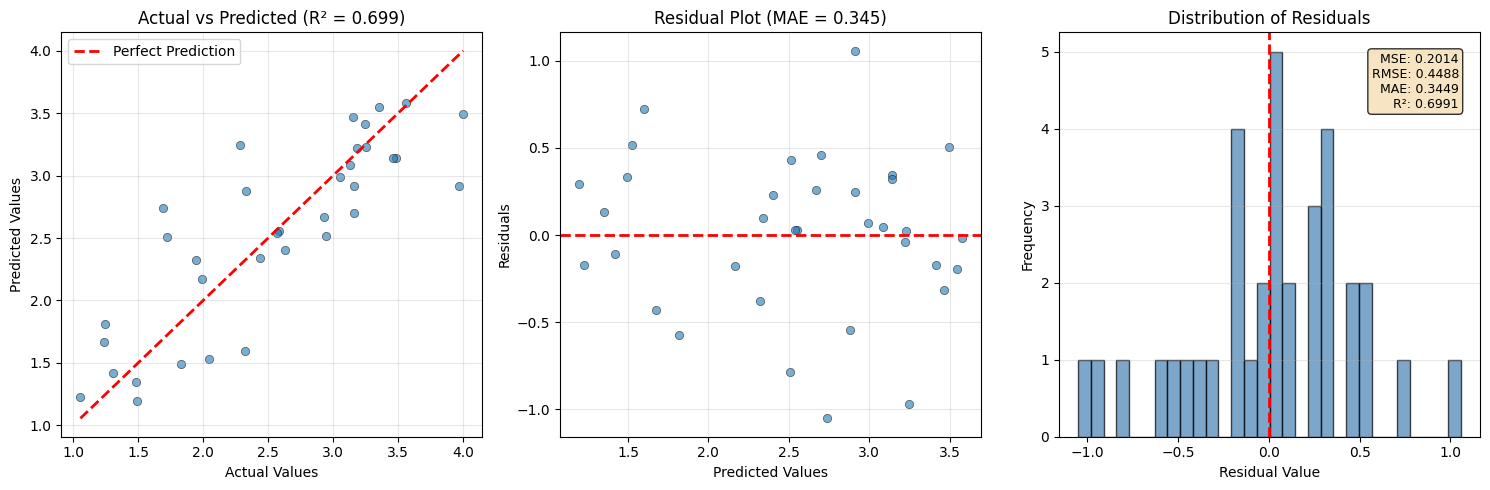

In [61]:
model.eval()
with torch.no_grad():
    X_test_tensor = torch.as_tensor(X_test, dtype=torch.float32, device=device)
    predictions = model(X_test_tensor).cpu().numpy()
    
    predictions = predictions.flatten()

    # Calculate metrics
    mse = mean_squared_error(Y_test, predictions)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(Y_test, predictions)
    r2 = r2_score(Y_test, predictions)
    
    # Print metrics
    print(f"\n{'='*50}")
    print(f"{'='*50}")
    print(f"MSE:  {mse:.4f}")
    print(f"RMSE: {rmse:.4f}")
    print(f"MAE:  {mae:.4f}")
    print(f"R²:   {r2:.4f}")
    
    # Create visualization
    fig, axes = plt.subplots(1, 3, figsize=(15, 5))
    
    # Plot 1: Actual vs Predicted
    axes[0].scatter(Y_test, predictions, alpha=0.6, edgecolors='k', linewidth=0.5)
    axes[0].plot([y_test.min(), Y_test.max()], [y_test.min(), Y_test.max()], 'r--', lw=2, label='Perfect Prediction')
    axes[0].set_xlabel('Actual Values')
    axes[0].set_ylabel('Predicted Values')
    axes[0].set_title(f'Actual vs Predicted (R² = {r2:.3f})')
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)
    
    # Plot 2: Residuals
    residuals = Y_test - predictions
    print(residuals.shape, predictions.shape)
    axes[1].scatter(predictions, residuals, alpha=0.6, edgecolors='k', linewidth=0.5)
    axes[1].axhline(y=0, color='r', linestyle='--', lw=2)
    axes[1].set_xlabel('Predicted Values')
    axes[1].set_ylabel('Residuals')
    axes[1].set_title(f'Residual Plot (MAE = {mae:.3f})')
    axes[1].grid(True, alpha=0.3)
    
    # Plot 3: Distribution of errors
    axes[2].hist(residuals, bins=30, alpha=0.7, edgecolor='black', color='steelblue')
    axes[2].axvline(x=0, color='r', linestyle='--', lw=2)
    axes[2].set_xlabel('Residual Value')
    axes[2].set_ylabel('Frequency')
    axes[2].set_title('Distribution of Residuals')
    axes[2].grid(True, alpha=0.3, axis='y')
    
    # Add text box with metrics
    metrics_text = f'MSE: {mse:.4f}\nRMSE: {rmse:.4f}\nMAE: {mae:.4f}\nR²: {r2:.4f}'
    axes[2].text(0.95, 0.95, metrics_text, transform=axes[2].transAxes,
                fontsize=9, verticalalignment='top', horizontalalignment='right',
                bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.8))
    
    plt.tight_layout()
    plt.show()


# DENSE Model

In [ ]:
from DENSE_model import *

# !!Data convertion 2d -> 1D !!
input_size = x_test.shape[1]

# Load champion dense model
dense_model_dir = "scoring_models/DENSE_models"
dense_model_path = os.path.join(dense_model_dir, "champion_model.pt")
dense_info_path = os.path.join(dense_model_dir, "champion_info.json")

# Load best state found during training
dense_state_dict = torch.load(dense_model_path, map_location=device)

with open(dense_info_path, "r") as f:
    dense_champion_info = json.load(f)

dense_champion_config = dense_champion_info["hyperparameters"]

# Re-build champion model
dense_champion = build_dense_model(dense_champion_config, input_size)
dense_champion.load_state_dict(dense_state_dict)
dense_champion.to(device)

# Summarize dense champion model
model_summary = summary(dense_champion, input_size=(1, input_size), col_names=["input_size", "output_size", "num_params", "trainable"])

print("DENSE CHAMPION MODEL SUMMARY")
print(model_summary)